# Nasdaq 100 index

### Testing with ADF, SADF, GSADF and BSADF

In [5]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# custom imports
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


##### 1. Download Nasdaq 100 index from 1. jan. 1990 to 31. dec. 2025

In [6]:
# Download Nasdaq 100, ticker = "^NDX" from yahoo finance
nasdaq = yf.Ticker("^NDX")
nasdaq_data = nasdaq.history(start="1990-01-01", end="2025-12-31", interval="1mo")
nasdaq_close = nasdaq_data["Close"]
log_nasdaq_close = np.log(nasdaq_close)

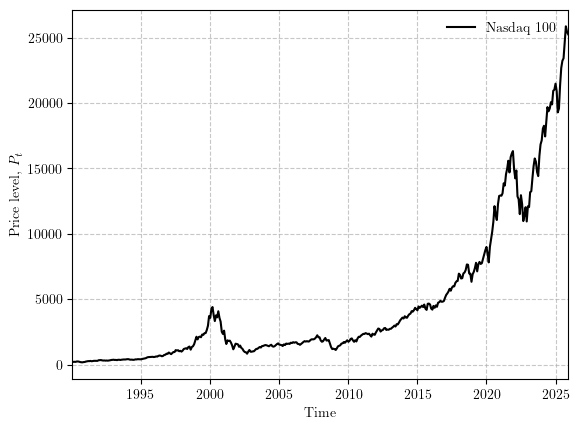

In [22]:
# LaTeX font settings
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# Plot
plt.plot(nasdaq_close.index, nasdaq_close, color="black", ls="-", label=r"Nasdaq 100")

plt.xlabel(r"Time")
plt.ylabel(r"Price level, $P_t$")
#plt.title(r"\textbf{Nasdaq 100 Index}")

# Fix x-axis
ax = plt.gca()
ax.set_xlim(nasdaq_close.index.min(), nasdaq_close.index.max())
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, alpha=0.7, ls="--")
plt.legend(frameon=False)

plt.savefig("plots/nasdaq100.pdf", bbox_inches="tight")
plt.show()

In [14]:
# download log and close as .csv
nasdaq_close.to_csv("data/nasdaq100.csv")
log_nasdaq_close.to_csv("data/log_nasdaq100.csv")

##### 2. We now display results of testing Nasdaq 100 index from 1. jan. 1990 to 31. dec. 2025
Results on untransformed prices, $P_t$:

In [ ]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/nasdaq100.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$Close)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/nasdaq100_bsadf_stat.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/nasdaq100_bsadf_cv.csv", row.names = FALSE)




── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id      adf      sadf     gsadf
  series1  4.15407  6.256398  6.256398

  gsadf_panel
     6.256398


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.39620743  1.151958  1.940131
   95  -0.03740744  1.450801  2.165954
   99   0.63280779  2.039598  2.622547

Error in library(kableExtra) : there is no package called ‘kableExtra’


RInterpreterError: Failed to parse and evaluate line 'library(exuber)\n\n# 1. Load series\ndat <- read.csv(\'data/nasdaq100.csv\') #../../data/simulated/timeseries/P_late_bubble.csv\ny   <- ts(dat$Close)     # change after $ to the column name\nT   <- length(y)\n\n# 2. Test statistics (ADF, SADF, GSADF)\nres  <- radf(y, lag = 0)\n\n# 3. Critical values (Monte Carlo)\ncv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)\n\noptions(digits = 10)\nprint(res)\nprint(cv)\n\n# BSADF critical values (90%, 95%, 99%) and test statistic\ncv$bsadf_cv # cv\nres$bsadf   # test statistic\n\n# download BSADF data\n\n# BSADF test statistic over time\nbsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))\nwrite.csv(bsadf_stat, "results/nasdaq100_bsadf_stat.csv", row.names = FALSE)\n\n# BSADF critical values (90, 95, 99)\nbsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns\nwrite.csv(bsadf_cv, "results/nasdaq100_bsadf_cv.csv", row.names = FALSE)\n\n\n# latex output \nlibra

BSADF with untransformed prices, $P_t$:

#### 4. We now display BSADF results of testing simulated late bubble from 1. jan. 2015 to 31. dec. 2025

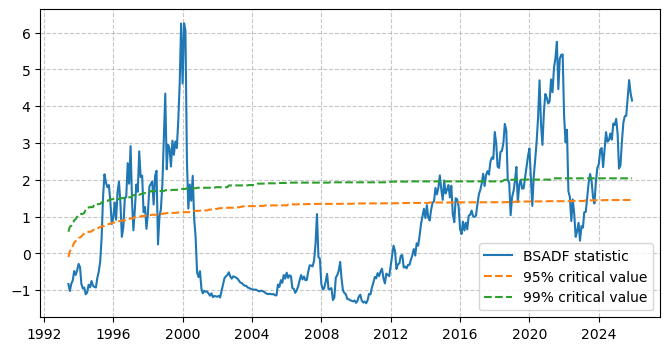

In [23]:
# download bsadf_stat.csv and bsadf_cv.csv
bsadf_stat = pd.read_csv("results/nasdaq100_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/nasdaq100_bsadf_cv.csv")

t = nasdaq_close.index[-len(bsadf_stat):]

plt.figure(figsize=(8, 4))
plt.plot(t, bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, bsadf_cv["99%"], "--", label="99% critical value")
plt.legend()
plt.grid(True, alpha=0.7, ls="--")
plt.savefig("plots/nasdaq100_bsadf.pdf", bbox_inches="tight")
plt.show()

Results on transformed prices, $\ln(P_t)$:

In [18]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/log_nasdaq100.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$Close)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/log_nasdaq100_bsadf_stat.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/log_nasdaq100_bsadf_cv.csv", row.names = FALSE)


── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id        adf      sadf     gsadf
  series1  -0.553682  2.144492  2.568401

  gsadf_panel
     2.568401


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.39620743  1.151958  1.940131
   95  -0.03740744  1.450801  2.165954
   99   0.63280779  2.039598  2.622547



BSADF with transformed prices, $\ln(P_t)$:

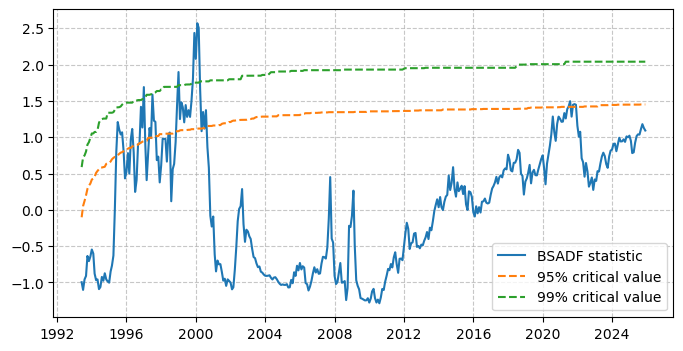

In [24]:
bsadf_stat = pd.read_csv("results/log_nasdaq100_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/log_nasdaq100_bsadf_cv.csv")

t = log_nasdaq_close.index[-len(bsadf_stat):]

plt.figure(figsize=(8, 4))
plt.plot(t, bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, bsadf_cv["99%"], "--", label="99% critical value")
plt.legend()
plt.grid(True, alpha=0.7, ls="--")
plt.savefig("plots/log_nasdaq100_bsadf.pdf", bbox_inches="tight")
plt.show()

## From 2015

##### 1. Download Nasdaq 100 index from 1. jan. 2015 to 31. dec. 2025

In [25]:
# Download Nasdaq 100, ticker = "^NDX" from yahoo finance
nasdaq = yf.Ticker("^NDX")
nasdaq_data = nasdaq.history(start="2015-01-01", end="2025-12-31", interval="1mo")
nasdaq_close = nasdaq_data["Close"]
log_nasdaq_close = np.log(nasdaq_close)

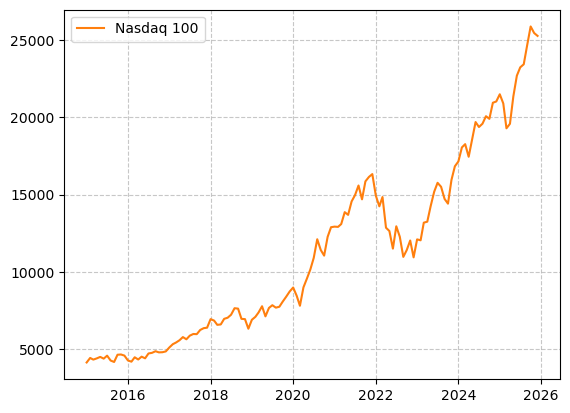

In [26]:
# Plot the Nasdaq 100 index
plt.plot(nasdaq_close.index, nasdaq_close, color="C1", ls="-", label="Nasdaq 100")
plt.grid(True, alpha=0.7, ls="--")
plt.legend()
plt.savefig("plots/2015_nasdaq100.pdf", bbox_inches="tight")
plt.show()

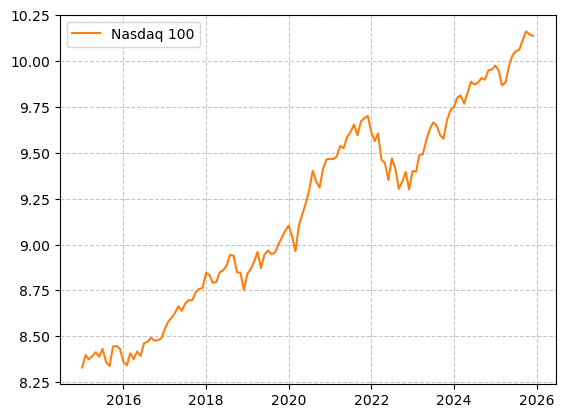

In [27]:
# Plot the Nasdaq 100 index with log scale
plt.plot(log_nasdaq_close.index, log_nasdaq_close, color="C1", ls="-", label="Nasdaq 100")
plt.grid(True, alpha=0.7, ls="--")
plt.legend()
plt.savefig("plots/2015_nasdaq100_log.pdf", bbox_inches="tight")
plt.show()

In [28]:
# download log and close as .csv
nasdaq_close.to_csv("data/2015_nasdaq100.csv")
log_nasdaq_close.to_csv("data/2015_log_nasdaq100.csv")

##### 2. We now display results of testing Nasdaq 100 index from 1. jan. 2015 to 31. dec. 2025
Results on untransformed prices, $P_t$:

In [19]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/2015_nasdaq100.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$Close)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/2015_nasdaq100_bsadf_stat.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/2015_nasdaq100_bsadf_cv.csv", row.names = FALSE)


── radf (minw = 22, lag = 0) ───────────────────────────────────────────────────

       id       adf      sadf     gsadf
  series1  1.123593  2.301198  2.357987

  gsadf_panel
     2.357987


── Monte Carlo (minw = 22, nrep = 2000) ────────────────────────────────────────

  sig         adf      sadf     gsadf
   90  -0.4496014  1.002152  1.771418
   95  -0.1377478  1.330626  2.052327
   99   0.6666404  1.930828  2.631734



BSADF with untransformed prices, $P_t$:

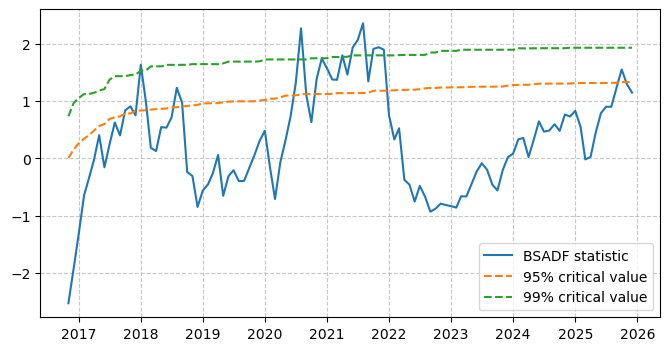

In [29]:
# download bsadf_stat.csv and bsadf_cv.csv
bsadf_stat = pd.read_csv("results/2015_nasdaq100_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/2015_nasdaq100_bsadf_cv.csv")

t = nasdaq_close.index[-len(bsadf_stat):]

plt.figure(figsize=(8, 4))
plt.plot(t, bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, bsadf_cv["99%"], "--", label="99% critical value")
plt.legend()
plt.grid(True, alpha=0.7, ls="--")
plt.savefig("plots/2015_nasdaq100_bsadf.pdf", bbox_inches="tight")
plt.show()

Results on transformed prices, $\ln(P_t)$:

In [20]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/2015_log_nasdaq100.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$Close)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/2015_log_nasdaq100_bsadf_stat.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/2015_log_nasdaq100_bsadf_cv.csv", row.names = FALSE)


── radf (minw = 22, lag = 0) ───────────────────────────────────────────────────

       id         adf       sadf     gsadf
  series1  -0.2630258  0.8011474  1.095263

  gsadf_panel
     1.095263


── Monte Carlo (minw = 22, nrep = 2000) ────────────────────────────────────────

  sig         adf      sadf     gsadf
   90  -0.4496014  1.002152  1.771418
   95  -0.1377478  1.330626  2.052327
   99   0.6666404  1.930828  2.631734



BSADF with transformed prices, $\ln(P_t)$:

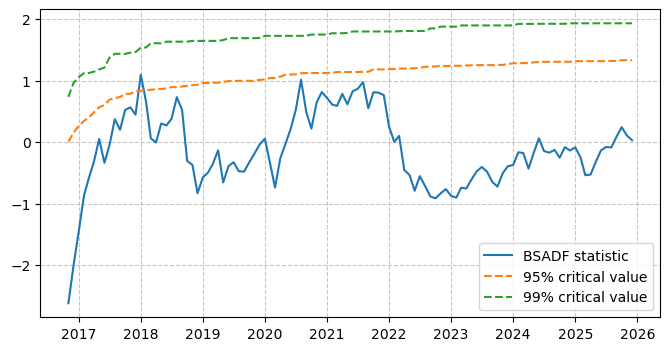

In [30]:
bsadf_stat = pd.read_csv("results/2015_log_nasdaq100_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/2015_log_nasdaq100_bsadf_cv.csv")

t = log_nasdaq_close.index[-len(bsadf_stat):]

plt.figure(figsize=(8, 4))
plt.plot(t, bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, bsadf_cv["99%"], "--", label="99% critical value")
plt.legend()
plt.grid(True, alpha=0.7, ls="--")
plt.savefig("plots/2015_log_nasdaq100_bsadf.pdf", bbox_inches="tight")
plt.show()